
Loading and preprocessing data...

Training the model...
Epoch 1/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 102s 191ms/step - accuracy: 0.5039 - loss: 1.6004 - val_accuracy: 0.7619 - val_loss: 0.7960 - learning_rate: 0.0010
Epoch 2/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 85s 178ms/step - accuracy: 0.6947 - loss: 0.9873 - val_accuracy: 0.8456 - val_loss: 0.5421 - learning_rate: 0.0010
Epoch 3/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 86s 181ms/step - accuracy: 0.7394 - loss: 0.8226 - val_accuracy: 0.8569 - val_loss: 0.4604 - learning_rate: 0.0010
Epoch 4/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 87s 183ms/step - accuracy: 0.7640 - loss: 0.7404 - val_accuracy: 0.8724 - val_loss: 0.4241 - learning_rate: 0.0010
Epoch 5/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 98s 206ms/step - accuracy: 0.7879 - loss: 0.6781 - val_accuracy: 0.8784 - val_loss: 0.3806 - learning_rate: 0.0010
Epoch 6/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 86s 182ms/step - accuracy: 0.7952 - loss: 0.6508 - val_accuracy: 0.8910 - val_loss: 0.3548 - learning_rate: 0.0010
Epoch 7/20



Evaluating model on test data...
149/149 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.9004 - loss: 0.3058
Test Accuracy: 0.9004, Test Loss: 0.3058

Saving training performance plot...


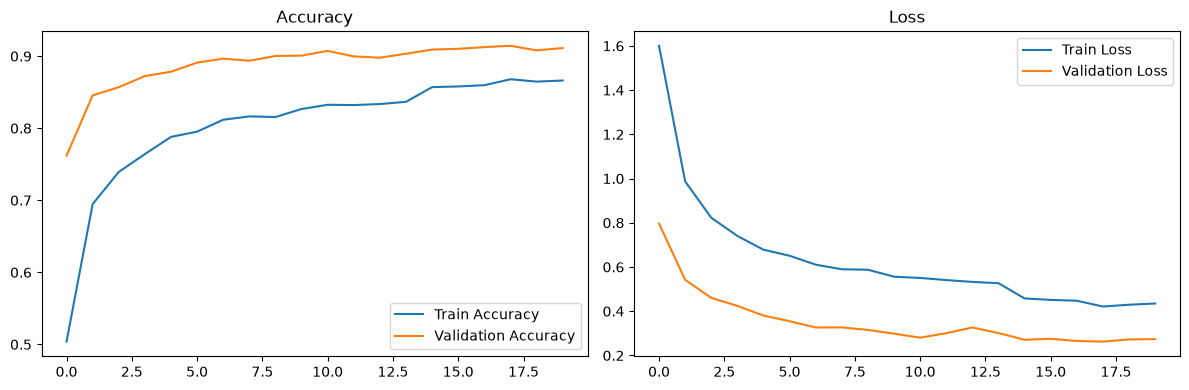

In [2]:
# Combined CNN + ULBP Training Script for PlantVillage Dataset

%matplotlib inline
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import feature
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import UnidentifiedImageError
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import pandas as pd

# 1. ULBP Feature Extraction

def extract_ulbp_features(image, num_points=24, radius=8, eps=1e-7):
    gray = np.mean(image, axis=2)
    gray = (gray * 255).astype("uint8")
    ulbp = feature.local_binary_pattern(gray, num_points, radius, method="default")
    hist, _ = np.histogram(ulbp.ravel(), bins=np.arange(0, num_points + 3), range=(0, num_points + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + eps)
    return hist

# 2. Data Loader

def load_and_preprocess_data(dataset_path, img_size=(128, 128)):
    images, labels, ulbp_features = [], [], []
    for label in os.listdir(dataset_path):
        label_path = os.path.join(dataset_path, label)
        if not os.path.isdir(label_path):
            continue
        for image_file in os.listdir(label_path):
            image_path = os.path.join(label_path, image_file)
            if image_file.startswith('.') or not image_file.lower().endswith(('png', 'jpg', 'jpeg')):
                continue
            try:
                image = load_img(image_path, target_size=img_size)
                image_array = img_to_array(image) / 255.0
                images.append(image_array)
                labels.append(label)
                ulbp_features.append(extract_ulbp_features(image_array))
            except UnidentifiedImageError:
                continue
    
    if not images:
        raise ValueError("No valid images found in dataset path.")

    images = np.array(images)
    ulbp_features = np.array(ulbp_features)
    labels = np.array(labels)

    le = LabelEncoder()
    labels_encoded = le.fit_transform(labels)
    labels_onehot = to_categorical(labels_encoded)

    return images, ulbp_features, labels_onehot, le

# 3. CNN + ULBP Model

def build_combined_cnn_model(image_input_shape, ulbp_input_shape, num_classes):
    image_input = Input(shape=image_input_shape, name="image_input")
    x = tf.keras.layers.RandomFlip("horizontal")(image_input)
    x = tf.keras.layers.RandomRotation(0.1)(x)
    x = tf.keras.layers.RandomZoom(0.1)(x)
    base_model = tf.keras.applications.MobileNetV2(input_shape=image_input_shape, include_top=False, weights="imagenet")
    base_model.trainable = False
    x = base_model(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)

    ulbp_input = Input(shape=(ulbp_input_shape,), name="ulbp_input")
    y = Dense(64, activation="relu")(ulbp_input)
    y = Dropout(0.5)(y)

    combined = Concatenate()([x, y])
    z = Dense(64, activation="relu")(combined)
    z = Dropout(0.5)(z)
    output = Dense(num_classes, activation="softmax")(z)

    model = Model(inputs=[image_input, ulbp_input], outputs=output)
    return model

# 4. Plotting and Evaluation Functions

def plot_training_history(history, path):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend(); plt.title("Accuracy")
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend(); plt.title("Loss")
    plt.tight_layout()
    plt.savefig(path)
    plt.show()

# 5. Main Execution

try:
    dataset_path = input("Enter the path to your 'plantvillage_dataset': ").strip()
    results_dir = "plantvillage_results"
    os.makedirs(results_dir, exist_ok=True)

    print("\nLoading and preprocessing data...")
    images, ulbp_features, labels, label_encoder = load_and_preprocess_data(dataset_path)
    num_classes = labels.shape[1]

    X_train_img, X_test_img, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
    X_train_ulbp, X_test_ulbp, _, _ = train_test_split(ulbp_features, labels, test_size=0.2, random_state=42)

    model = build_combined_cnn_model(X_train_img.shape[1:], X_train_ulbp.shape[1], num_classes)
    model.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

    callbacks = [
        EarlyStopping(patience=5, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-6),
        ModelCheckpoint(os.path.join(results_dir, "best_model.weights.h5"), save_best_only=True,
                        save_weights_only=True, monitor="val_accuracy", mode="max")
    ]

    print("\nTraining the model...")
    history = model.fit(
        [X_train_img, X_train_ulbp], y_train,
        epochs=20, batch_size=32,
        validation_split=0.2,
        callbacks=callbacks
    )

    model.save(os.path.join(results_dir, "full_model.h5"))
    with open(os.path.join(results_dir, "training_history.pkl"), "wb") as f:
        pickle.dump(history.history, f)
    with open(os.path.join(results_dir, "label_encoder.pkl"), "wb") as f:
        pickle.dump(label_encoder, f)

    print("\nEvaluating model on test data...")
    test_loss, test_acc = model.evaluate([X_test_img, X_test_ulbp], y_test)
    print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

    print("\nSaving training performance plot...")
    plot_training_history(history, os.path.join(results_dir, "training_performance.png"))

except Exception as e:
    print("\nError occurred:", str(e))
